<div style="background-color:#f0f4f8; padding:20px; border-radius:10px;">

# THE DIET PROBLEM

---

## Goal of Our Project

- Create an interface where a user can input their age, weight, sex and height as parameters and the program will output an optimised diet at a minimum cost.
- The program will internally calculate all necessary macronutritional values and output a combination of foods that fulfill all parameters at a minimised cost.
- The user should then be able to take this list and use it to aid them in their weekly shop.


---

## Rationale
- We originally encountered a problem similar to this in our Management Science Module, where we were tasked with finding the minimised combination of a given set of 6 foods subject to some dietary constrains by hand using the Simplex Method.
- It was a topic that was of particular interest to use as college students doing our weekly shop on a tight budget (so we could save for more important stuff like our T-Ball ticket 💃🕺)
- However, the method we used was lenghty, complicated and error-prone (if you made a simple mistake, the whole solution came crashing down). It also gave unrealistic outputs that would not realistically sustain a well-balanced diet.
- We decided to try to create an interface that any user, computer wizz or not, can use simply without error or confusing. it would generate a shopping list from the entirity of the available food in a supermarket and be tailored to generate the best combination for any user needs (nutritional or preferential).


<div style="text-align:center; padding:20px;">
    <img src="healthyFood.jpg" width="600" style="border-radius:15px; box-shadow: 0px 4px 15px rgba(0,0,0,0.3);">
    <p style="font-family:Georgia; color:grey; font-size:30px; margin-top:10px;">
        Eat well, spend less
    </p>
</div>


## Step 1
### - Importing Essential Libraries


---
1. pandas: for reading and manipulating the dataset.
2. numpy: for mathematical operations on arrays etc.
3. re: used to get rid of non numerical data in the data set (like currencies or weights).
4. pulp: found this lib in some of the youtube videos we watched. Its used to solve a LP problem subject to constrains. Perfect for our project goals 🤗.
5. warnings - gets rid of warning messages that may clutter our output.

---

In [15]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp", "pandas", "numpy", "--quiet"])

import pandas as pd
import numpy as np
import pulp
import re
import warnings
warnings.filterwarnings('ignore')


## Step 2:

### -    Loading and Cleaning the Dataset
---

Dataset comes from Tesco UK. Downloaded from Kaggle

In [16]:
data = pd.read_csv("DietProblemDataV2.csv")

---
Imported data was messy - many cells being empty, containing units, using commas instead of decimal points.
The parse-numeric function below strips anything that isnt a number and returns a clean float value.

---

In [17]:
def parse_numeric(val):
    if pd.isna(val): return 0.0          # if the cell is empty (NaN), return 0
    s = str(val).strip()
    if s == '' or s == '-': return 0.0
    if s.startswith('<'): return 0.0     # nutriens in only trace amounts are returned as 0 too
    s = re.sub(r'\s*\(.*?\)', '', s)
    s = re.sub(r'[gG€%]', '', s)
    s = s.replace(',', '.').strip()
    try: return float(s)
    except: return 0.0                   # if it cant be converted to a clean float, return 0

---

Building the clean data frame.
This creates a clean table with defined rows (food product) and columns (nutritional values & price)

---

In [19]:
df = pd.DataFrame() #cleaned data stored in df

df['name']           = data['Product Name'].str.strip() #change name and get rid of space
df['price_eur']      = data['Price (€)'].apply(parse_numeric) #runs through parse to get a clean number (.apply calls the function row by row)
df['pack_g']         = data['Pack Size (g)'].apply(parse_numeric)
df['servings']       = data['Serving Size (servings)'].apply(parse_numeric)
df['energy_kcal']    = data['Energy (kcal)'].apply(parse_numeric)
df['fat_g']          = data['Fat (g)'].apply(parse_numeric)
df['saturates_g']    = data['Saturates (g)'].apply(parse_numeric)
df['carbs_g']        = data['Carbohydrates (g)'].apply(parse_numeric)
df['sugars_g']       = data['Sugars (g)'].apply(parse_numeric)
df['fibre_g']        = data['Fibre (g)'].apply(parse_numeric)
df['protein_g']      = data['Protein (g)'].apply(parse_numeric)
df['salt_g']         = data['Salt (g)'].apply(parse_numeric)



df = df[(df['price_eur'] > 0) & (df['pack_g'] > 0) & (df['servings'] > 0)].copy() #gets rid of rows where size is 0
df = df.reset_index(drop=True) #resets row number
df['cost_per_serving'] = df['price_eur'] / df['servings']
df['serving_g']        = df['pack_g'] / df['servings'] #weight of 1 serving in grams

print(f"{len(df)} usable food products")
display(df[['name','price_eur','servings','cost_per_serving','energy_kcal',
            'fat_g','carbs_g','protein_g','fibre_g','salt_g']].head())

51 usable food products


,name,price_eur,servings,cost_per_serving,energy_kcal,fat_g,carbs_g,protein_g,fibre_g,salt_g
0,Crispy Pancakes Beef & Onion,2.57,4.0,0.642500,274.0,15.0,26.0,8.2,1.1,0.72
1,Hearty Food Co Mac 'N' Cheese,0.76,1.0,0.760000,121.0,2.7,19.3,4.4,1.1,0.62
2,Dijon Mustard,2.34,37.0,0.063243,128.0,9.2,3.7,6.2,2.7,6.20
3,Wholemeal Seeds And Grains Bread,2.50,18.0,0.138889,254.0,5.0,37.4,11.7,6.4,0.98
4,Gastro Cod Parmesan Parsley 2 F/Cakes,1.17,2.0,0.585000,180.0,7.0,18.7,9.9,1.0,0.70


In [20]:
print(" 👇 Enter your details below 👇 \n")

AGE       = int(input("Enter your age (years): "))
SEX       = input("Enter your sex (male/female): ").strip().lower()

# the user can choose if they want to put their measurements in metric or impreial
height_unit = input("Would you like to enter your height in cm or feet? (cm/feet): ").strip().lower()
if height_unit == 'feet':
    feet   = float(input("Enter feet: "))
    inches = float(input("Enter inches (enter 0 if none): "))
    HEIGHT_CM = round((feet * 30.48) + (inches * 2.54), 1)
    print(f"  Converting to cm: {HEIGHT_CM}cm")
else:
    HEIGHT_CM = float(input("Enter your height (cm): "))


weight_unit = input("Would you like to enter your weight in kg or lbs? (kg/lbs): ").strip().lower()
if weight_unit == 'lbs':
    weight_lbs = float(input("Enter your weight (lbs): "))
    WEIGHT_KG  = round(weight_lbs * 0.453592, 1)
    print(f"  Converting to kg: {WEIGHT_KG}kg")
else:
    WEIGHT_KG = float(input("Enter your weight (kg): "))

# we put activity levels as pick an option instead of type to avoid typos which would lead to errors
print("\nActivity level options:")
print("  A: Inactive       (desk job, little exercise)")
print("  B: Lightly Active  (light exercise 1-3 days/week)")
print("  C: Moderately Active (moderate exercise 3-5 days/week)")
print("  D: Very Active     (hard exercise 6-7 days/week)")
print("  E: Extra Active    (very hard exercise / physical job)")

activity_choice = input("Enter your activity level (A/B/C/D/E): ").strip().upper()

activity_map = {
    'A': 'inactive',
    'B': 'lightly_active',
    'C': 'moderately_active',
    'D': 'very_active',
    'E': 'extra_active'
}
ACTIVITY = activity_map.get(activity_choice, 'moderately_active')
print(f"  Selected: {ACTIVITY.replace('_',' ').title()}")

print("-" * 28)
print(f"""
  Here are the details you entered

  Age      : {AGE} years old
  Sex      : {SEX.capitalize()}
  Height   : {HEIGHT_CM}cm

  Weight   : {WEIGHT_KG}kg
  Activity : {ACTIVITY.replace('_',' ').title()}
""")
print("-" * 28)

 👇 Enter your details below 👇 

Enter your age (years): 20
Enter your sex (male/female): male
Would you like to enter your height in cm or feet? (cm/feet): feet
Enter feet: 6
Enter inches (enter 0 if none): 0
  Converting to cm: 182.9cm
Would you like to enter your weight in kg or lbs? (kg/lbs): kg
Enter your weight (kg): 74

Activity level options:
  A: Inactive       (desk job, little exercise)
  B: Lightly Active  (light exercise 1-3 days/week)
  C: Moderately Active (moderate exercise 3-5 days/week)
  D: Very Active     (hard exercise 6-7 days/week)
  E: Extra Active    (very hard exercise / physical job)
Enter your activity level (A/B/C/D/E): B
  Selected: Lightly Active
----------------------------

  Here are the details you entered
       
  Age      : 20 years old 
  Sex      : Male
  Height   : 182.9cm
      
  Weight   : 74.0kg
  Activity : Lightly Active

----------------------------


In [21]:
if SEX.lower() == 'male':
    bmr = 10 * WEIGHT_KG + 6.25 * HEIGHT_CM - 5 * AGE + 5
else:
    bmr = 10 * WEIGHT_KG + 6.25 * HEIGHT_CM - 5 * AGE - 161

activity_factors = {
    'inactive': 1.2, 'lightly_active': 1.375,
    'moderately_active': 1.55, 'very_active': 1.725, 'extra_active': 1.9
}
tdee = bmr * activity_factors.get(ACTIVITY, 1.55)

protein_factor = 1.2 if ACTIVITY in ('moderately_active','very_active','extra_active') else 0.8
protein_min = round(protein_factor * WEIGHT_KG, 1)
protein_max = round(2.0 * WEIGHT_KG, 1)
fat_min     = round(0.20 * tdee / 9, 1)
fat_max     = round(0.35 * tdee / 9, 1)
sat_max     = round(0.10 * tdee / 9, 1)
carb_min    = round(0.45 * tdee / 4, 1)
carb_max    = round(0.65 * tdee / 4, 1)
sugar_max   = round(0.10 * tdee / 4, 1)
fibre_min   = 30.0 if AGE >= 18 else 25.0
salt_max    = 6.0

print(f"""
  Based on your details, your estimated calorie needs are:

  At complete rest: {bmr:.0f} kcal/day
  Accounting for activity level : {tdee:.0f} kcal/day

  Overall daily nutrient targets are:

  Energy      : {tdee:.0f} kcal
  Protein     : between {protein_min}g and {protein_max}g
  Fat         : between {fat_min}g and {fat_max}g
  Saturates   : no more than {sat_max}g
  Carbs       : between {carb_min}g and {carb_max}g
  Sugars      : no more than {sugar_max}g
  Fibre       : at least {fibre_min}g
  Salt        : no more than {salt_max}g
""")


  Based on your details, your estimated calorie needs are:

  At complete rest: 1788 kcal/day 
  Accounting for activity level : 2459 kcal/day 

  Overall daily nutrient targets are:
  
  Energy      : 2459 kcal
  Protein     : between 59.2g and 148.0g
  Fat         : between 54.6g and 95.6g
  Saturates   : no more than 27.3g
  Carbs       : between 276.6g and 399.5g
  Sugars      : no more than 61.5g
  Fibre       : at least 30.0g
  Salt        : no more than 6.0g



## Step 3:
### - Pie Chart of Your Daily Nutrient Targets

---
This pie chart shows the user visually how much they need of each nutrient group - kind of like how much space each nutrient group should take up on their plate :)

---

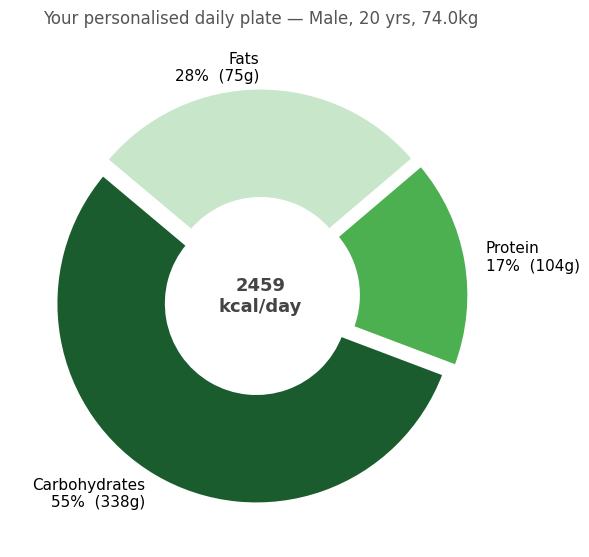

In [22]:
import matplotlib.pyplot as plt

prot_mid  = (protein_min + protein_max) / 2
fat_mid   = (fat_min + fat_max) / 2
carb_mid  = (carb_min + carb_max) / 2

prot_kcal  = prot_mid * 4
fat_kcal   = fat_mid  * 9
carb_kcal  = carb_mid * 4
total_kcal = prot_kcal + fat_kcal + carb_kcal

prot_pct = prot_kcal / total_kcal * 100
fat_pct  = fat_kcal  / total_kcal * 100
carb_pct = carb_kcal / total_kcal * 100

labels = [
    f"Carbohydrates\n{carb_pct:.0f}%  ({carb_mid:.0f}g)",
    f"Protein\n{prot_pct:.0f}%  ({prot_mid:.0f}g)",
    f"Fats\n{fat_pct:.0f}%  ({fat_mid:.0f}g)",
]
sizes   = [carb_pct, prot_pct, fat_pct]
colors  = ["#1a5c2e", "#4caf50", "#c8e6c9"]
explode = (0.04, 0.04, 0.04)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11),
)
ax.text(0, 0, f"{tdee:.0f}\nkcal/day",
        ha="center", va="center", fontsize=13, fontweight="bold", color="#444")
ax.set_title(
    f"Your personalised daily plate — "
    f"{SEX.capitalize()}, {AGE} yrs, {WEIGHT_KG}kg",
    fontsize=12, pad=16, color="#555"
)
plt.tight_layout()
plt.savefig("piechart.png", bbox_inches='tight', transparent=True)

## Step 4:
### - Realism Settings

---

must have at least 5 food items and not more than 4 servings per day of any individual item. This makes sure we're not just eating the same bland food every day.

---


In [26]:

MAX_SERVINGS_PER_FOOD = 4
MIN_FOODS_IN_PLAN     = 5

print(f"""
  Realism settings:
  Max servings per food : {MAX_SERVINGS_PER_FOOD}
  Min different foods   : {MIN_FOODS_IN_PLAN}
  Daily budget cap      : {'€' + str(DAILY_BUDGET_EUR) if DAILY_BUDGET_EUR else 'No budget'}
""")


  Realism settings:
  Max servings per food : 4
  Min different foods   : 5
  Daily budget cap      : No budget



## Step 5:
### - The Solver

---
This is where the magic happens. By implementing the PuLP library whe can use linear programming to solve for the cheapest combination of foods you can purchase from Tesco which fulfill all your daily nutrient requirements.

---

In [27]:
def solve_diet():
    scale   = 7 # 7 days in week so multiple nutri needs by this
    indices = list(df.index)

    prob = pulp.LpProblem("DietOptimiser", pulp.LpMinimize) # our linear programming solver


    # decision variable x is how many packets to buy of various food groups
    x = pulp.LpVariable.dicts("packs", indices, lowBound=0,
                               upBound=4, cat='Integer')
    # 1 if variable is bought, 0 otherwise.
    y = pulp.LpVariable.dicts("used", indices, cat='Binary')

    # our objective is to minimise cost - but you still have to buy a whole packet not just a serving size to make this more realistic
    prob += pulp.lpSum(df.loc[i, 'price_eur'] * x[i] for i in indices)

    for i in indices:
        prob += x[i] <= 4 * y[i]
        prob += x[i] >= y[i]

    # nutritional contribution ie. packs * servings per pack * nutrients per serving
    def total(nutrient):
        return pulp.lpSum(
            df.loc[i, nutrient] * df.loc[i, 'servings'] * x[i]
            for i in indices
        )

    prob += total('energy_kcal') >= tdee * scale * 0.90
    prob += total('energy_kcal') <= tdee * scale * 1.10
    prob += total('protein_g')   >= protein_min * scale
    prob += total('protein_g')   <= protein_max * scale
    prob += total('fat_g')       >= fat_min * scale
    prob += total('fat_g')       <= fat_max * scale
    prob += total('saturates_g') <= sat_max * scale
    prob += total('carbs_g')     >= carb_min * scale
    prob += total('carbs_g')     <= carb_max * scale
    prob += total('sugars_g')    <= sugar_max * scale
    prob += total('fibre_g')     >= fibre_min * scale
    prob += total('salt_g')      <= salt_max * scale

    prob += pulp.lpSum(y[i] for i in indices) >= MIN_FOODS_IN_PLAN


    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    if pulp.LpStatus[prob.status] != 'Optimal':
        from IPython.display import HTML, display
        display(HTML("""
            <div style="text-align:center; padding:20px;">
                <p style="font-family:Georgia; color:black; font-size:20px; font-style:italic;">
                    Uh oh... No solution found. Try increasing your budget...<br>
                    maybe you can't afford that T-Ball ticket after all!
                </p>
            </div>
        """))
        return None

    rows = []
    for i in indices:
        packs = int(round(pulp.value(x[i])))
        if packs > 0:
            row = df.loc[i].copy()
            total_servings        = packs * row['servings']
            row['packs_to_buy']   = packs
            row['total_cost_€']   = round(row['price_eur'] * packs, 2)
            row['total_energy']   = round(row['energy_kcal'] * total_servings, 1)
            row['total_protein']  = round(row['protein_g']  * total_servings, 1)
            row['total_fat']      = round(row['fat_g']       * total_servings, 1)
            row['total_carbs']    = round(row['carbs_g']     * total_servings, 1)
            row['total_fibre']    = round(row['fibre_g']     * total_servings, 1)
            row['total_salt']     = round(row['salt_g']      * total_servings, 1)
            row['daily_energy']   = round(row['total_energy'] / 7, 1)
            row['daily_protein']  = round(row['total_protein'] / 7, 1)
            row['daily_fat']      = round(row['total_fat'] / 7, 1)
            row['daily_carbs']    = round(row['total_carbs'] / 7, 1)
            row['daily_fibre']    = round(row['total_fibre'] / 7, 1)
            row['daily_salt']     = round(row['total_salt'] / 7, 1)
            rows.append(row)

    results = pd.DataFrame(rows).reset_index(drop=True)
    total_cost = round(pulp.value(prob.objective), 2)

    print(f"\n{'='*55}")
    print(f"  🛒  WEEKLY SHOPPING LIST   (total: €{total_cost:.2f})")
    print(f"{'='*55}")
    print(f"  {'Product':<40} {'Packs':>5}  {'Cost':>6}")
    print(f"  {'-'*54}")
    for _, row in results.iterrows():
        print(f"  {str(row['name'])[:40]:<40} {int(row['packs_to_buy']):>5}  €{row['total_cost_€']:>5.2f}")
    print(f"  {'-'*54}")
    print(f"  {'TOTAL WEEKLY COST':<48} €{total_cost:.2f}")
    print(f"  {'AVERAGE DAILY COST':<48} €{total_cost/7:.2f}")

    print(f"\n{'='*55}")
    print(f"  🍽️   WHAT TO EAT EACH DAY")
    print(f"{'='*55}")
    print(f"  {'Product':<40} {'Servings/day':>12}")
    print(f"  {'-'*54}")
    for _, row in results.iterrows():
        daily_sv = round((row['packs_to_buy'] * row['servings']) / 7, 1)
        print(f"  {str(row['name'])[:40]:<40} {daily_sv:>12.1f}")

    print(f"\n  Daily nutrient totals vs targets:")
    print(f"  Energy   : {results['daily_energy'].sum():.0f} kcal  (target: {tdee:.0f})")
    print(f"  Protein  : {results['daily_protein'].sum():.1f}g  (target: {protein_min:.0f}–{protein_max:.0f}g)")
    print(f"  Fat      : {results['daily_fat'].sum():.1f}g  (target: {fat_min:.0f}–{fat_max:.0f}g)")
    print(f"  Carbs    : {results['daily_carbs'].sum():.1f}g  (target: {carb_min:.0f}–{carb_max:.0f}g)")
    print(f"  Fibre    : {results['daily_fibre'].sum():.1f}g  (target: ≥{fibre_min:.0f}g)")
    print(f"  Salt     : {results['daily_salt'].sum():.1f}g  (target: ≤{salt_max:.0f}g)")
    print(f"{'='*55}")

    from IPython.display import HTML, display
    display(HTML("""
        <div style="text-align:center; padding:20px;">
            <p style="font-family:Georgia; color:black; font-size:20px; font-style:italic;">
                Look at you, eating well on a budget! 🤑
            </p>
        </div>
    """))

    return results

results = solve_diet()



  🛒  WEEKLY SHOPPING LIST   (total: €7.78)
  Product                                  Packs    Cost
  ------------------------------------------------------
  Hearty Food Co Mac 'N' Cheese                1  € 0.76
  Wholemeal Seeds And Grains Bread             1  € 2.50
  Easy Cook Brown Rice                         1  € 2.00
  Sea Salt & Black Pepper Cracker              1  € 1.52
  Mango & Passion Fruit Mousse                 1  € 1.00
  ------------------------------------------------------
  TOTAL WEEKLY COST                                €7.78
  AVERAGE DAILY COST                               €1.11

  🍽️   WHAT TO EAT EACH DAY
  Product                                  Servings/day
  ------------------------------------------------------
  Hearty Food Co Mac 'N' Cheese                     0.1
  Wholemeal Seeds And Grains Bread                  2.6
  Easy Cook Brown Rice                              3.7
  Sea Salt & Black Pepper Cracker                   2.3
  Mango & Passion Fr